In [1]:
# ----- Libraries -----

import pandas as pd
import re             # searches, finds matches and manipulates string data based on patterns
import string         # a library for special characters (easy to define characters)
from sklearn.model_selection import train_test_split
# TfidfVectorizer: converts raw texts into matrixes to determine the frequency and uniqueness
# ENGLISH_STOP_WORDS: creates a custom lists to remove words
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

### Data Loading and Column Renaming

In [2]:
# ----- Data Loading and Column Renaming -----

df = pd.read_csv('shampoo_final_dataset.tsv', sep = '\t')

df.columns.tolist()

['r.rating',
 'r.review_title',
 'r.review_text',
 'r.user_id',
 'r.review_timestamp',
 'r.verified_purchase',
 'r.helpful_vote',
 'p.product_title',
 'p.main_category',
 'p.average_rating',
 'p.rating_number',
 'p.price',
 'p.categories']

In [3]:
    # This happened because the dataset was exported from Hive without any column name change. The columns need to be renamed.

df.rename(columns = {
    'r.rating': 'rating',
    'r.review_title': 'review_title',
    'r.review_text': 'review_text',
    'r.user_id': 'user_id',
    'r.review_timestamp': 'review_timestamp',
    'r.verified_purchase': 'verified_purchase',
    'r.helpful_vote': 'helpful_vote',
    'p.product_title': 'product_title',
    'p.main_category': 'main_category',
    'p.average_rating': 'average_rating',
    'p.rating_number': 'rating_number',
    'p.price': 'price',
    'p.categories': 'categories'
}, inplace = True
         )

### Sentiment Labeling and Data Preparation

In [4]:
# ----- Negative Sentiment Labeling and Data Preparation -----

    # On the rating scale (1 to 5):
    # 4 and 5 means that customer was satisfied (positive) -> labeled as 1.
    # 1 and 2 represent unhappy customers (negative).      -> labeled as 0.
    # 3 is where the reviews are usually ambigious (both positive and negative sentiment). This will prevent the training model to properly
# learn the relationship between the ratings and sentiments. So, they are removed from the dataset.

df = df[df['rating'] != 3]

df['sentiment'] = df['rating'].apply(lambda x: 1 if x > 3 else 0)


    # Sometimes a customer only provides feedback on the review title and leaves the text body empty. Also, the title provides important
# information on the sentiment. This is why both columns will be merged.
    # To prevent crashing, the null values will be filled with ''.

df['review_title'] = df['review_title'].fillna('')
df['review_text'] = df['review_text'].fillna('')

df['feedback'] = df['review_title'] + ' ' + df['review_text']

    # To ensure consistency, all values in feedback will be converted to string and all whitespaces will be removed.

df['feedback'] = df['feedback'].astype(str).str.strip()

    # If both columns are empty, the rows will not be meaningful and useful for the machine learning. They need to be removed.

df = df[df['feedback'] != '']
df.head(5)

,rating,review_title,review_text,user_id,review_timestamp,verified_purchase,helpful_vote,product_title,main_category,average_rating,rating_number,price,categories,sentiment,feedback
0,5.0,Love it,I love this shampoo and conditioner.. my hair ...,AGQLV5VZGMUXHA2Z6HD2JFKGPOVQ,1578199773833,True,0,WOW Skin Science Apple Cider Vinegar Shampoo &...,All Beauty,4.0,73787,15.3,"[""Beauty & Personal Care"",""Hair Care"",""Shampoo...",1,Love it I love this shampoo and conditioner.. ...
1,2.0,Not as expected,Made my hair very dry and unmanageable.,AGH5HQH2WB64VHVDVP4AEPKUPBVA,1604693366680,True,0,WOW Skin Science Apple Cider Vinegar Shampoo &...,All Beauty,4.0,73787,15.3,"[""Beauty & Personal Care"",""Hair Care"",""Shampoo...",0,Not as expected Made my hair very dry and unma...
2,5.0,Awesome,Love love this shampoo,AHG67MGKBZ7NT5IHCQWZ34QFOIOA,1630537639493,True,0,WOW Skin Science Apple Cider Vinegar Shampoo &...,All Beauty,4.0,73787,15.3,"[""Beauty & Personal Care"",""Hair Care"",""Shampoo...",1,Awesome Love love this shampoo
3,5.0,Manageable hair,So far with only a few shampooing & conditioni...,AHERSO23CCGOZAFMYKPFLEYRX26A,1582034045929,True,0,WOW Skin Science Apple Cider Vinegar Shampoo &...,All Beauty,4.0,73787,15.3,"[""Beauty & Personal Care"",""Hair Care"",""Shampoo...",1,Manageable hair So far with only a few shampoo...
4,5.0,Good combo!,I like this product as it comes with both sham...,AFIT2536PTXLRDXAOHQP6S7FFANQ,1580573925774,True,0,WOW Skin Science Apple Cider Vinegar Shampoo &...,All Beauty,4.0,73787,15.3,"[""Beauty & Personal Care"",""Hair Care"",""Shampoo...",1,Good combo! I like this product as it comes wi...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12467 entries, 0 to 13699
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rating             12467 non-null  float64
 1   review_title       12467 non-null  object 
 2   review_text        12467 non-null  object 
 3   user_id            12467 non-null  object 
 4   review_timestamp   12467 non-null  int64  
 5   verified_purchase  12467 non-null  bool   
 6   helpful_vote       12467 non-null  int64  
 7   product_title      12467 non-null  object 
 8   main_category      12467 non-null  object 
 9   average_rating     12467 non-null  float64
 10  rating_number      12467 non-null  int64  
 11  price              12467 non-null  float64
 12  categories         12467 non-null  object 
 13  sentiment          12467 non-null  int64  
 14  feedback           12467 non-null  object 
dtypes: bool(1), float64(3), int64(4), object(7)
memory usage: 1.4+ MB


### Data Cleaning and Preprocessing

In [6]:
# ----- Data Cleaning and Preprocessing -----

df['cleaned_feedback'] = df['feedback']        # creating a column where we can manipulate data and at the same time protecting the raw data

df['cleaned_feedback'] = df['feedback'].str.lower() # turning all string characters lowercase
df['cleaned_feedback'] = df['cleaned_feedback'].str.replace(r'[^\w\s]', '', regex = True) # punctuations aren't necessary to the analysis
df['cleaned_feedback'] = df['cleaned_feedback'].str.replace(r'<.+?>', '', regex = True)   # HTML tags aren't relevant to the analysis
df['cleaned_feedback'] = df['cleaned_feedback'].str.replace(r'\d+', '', regex = True)     # numbers aren't relevant due to the nature of 
                                                                                                # the analysis

# Comparing the cleaned feedback with the raw feedback to see whether the changes are applied.
df[['feedback', 'cleaned_feedback']].head(5)

,feedback,cleaned_feedback
0,Love it I love this shampoo and conditioner.. ...,love it i love this shampoo and conditioner my...
1,Not as expected Made my hair very dry and unma...,not as expected made my hair very dry and unma...
2,Awesome Love love this shampoo,awesome love love this shampoo
3,Manageable hair So far with only a few shampoo...,manageable hair so far with only a few shampoo...
4,Good combo! I like this product as it comes wi...,good combo i like this product as it comes wit...


### Sentiment Analysis

#### Vectorization and Model Training

In [7]:
# ----- Vectorization and Model Training -----

    # TfidfVectorizer finds the meaningful (frequent and unique) words in raw strings. However, english uses a lot of meaningless words
# (e.g. at, the, in, etc.) so these need to be removed. 
    # To speed up the processing time, a word limit has been put. The model will only look at the 5000 most important words.

tfidf = TfidfVectorizer(stop_words = 'english', max_features = 5000)

X = tfidf.fit_transform(df['cleaned_feedback'])     # the training feature is the customer feedback
y = df['sentiment']                                 # the target is the sentiment

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


#### Evaluation of the Model

In [8]:
# ----- Evaluation and the Visualization of the Model -----

y_pred = model.predict(X_test)

report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.91      0.82      0.86       786
           1       0.92      0.96      0.94      1708

    accuracy                           0.92      2494
   macro avg       0.92      0.89      0.90      2494
weighted avg       0.92      0.92      0.92      2494



In [9]:
cmatrix = confusion_matrix(y_test, y_pred)
cmatrix

array([[ 641,  145],
       [  61, 1647]])

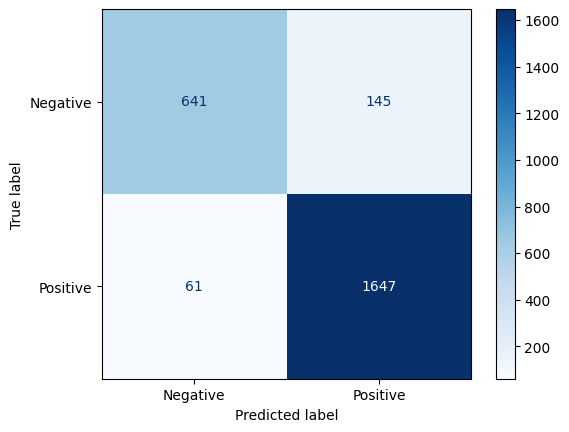

In [10]:
cmatrix_display = ConfusionMatrixDisplay(confusion_matrix = cmatrix, display_labels = ['Negative', 'Positive'])
cmatrix_display.plot(cmap = 'Blues')

#### Top Defects

In [11]:
coefficients = model.coef_[0]
feature_names = tfidf.get_feature_names_out()
coeff_df = pd.DataFrame({'Word': feature_names, 'Coefficient': coefficients})

top_negative = coeff_df.sort_values(by = 'Coefficient').head(15)

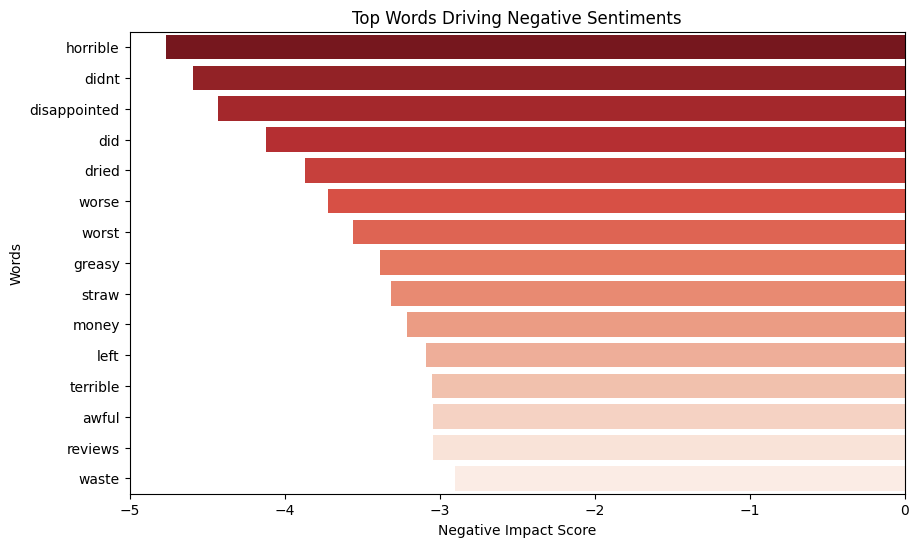

In [12]:
plt.figure(figsize = (10,6))
sns.barplot( x = 'Coefficient', y = 'Word', data = top_negative, palette = 'Reds_r', hue = 'Word', legend = False)
plt.title('Top Words Driving Negative Sentiments')
plt.xlabel('Negative Impact Score')
plt.ylabel('Words')
plt.show()

In [47]:
# ----- Evaluation and Visualization -----

y_pred = model_phrase.predict(X_test)

report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.32      0.06      0.10       786
           1       0.68      0.94      0.79      1708

    accuracy                           0.66      2494
   macro avg       0.50      0.50      0.45      2494
weighted avg       0.57      0.66      0.57      2494



In [15]:
cmatrix_phrase = confusion_matrix(y_test, y_pred)
cmatrix_phrase

array([[ 539,  247],
       [  41, 1667]])

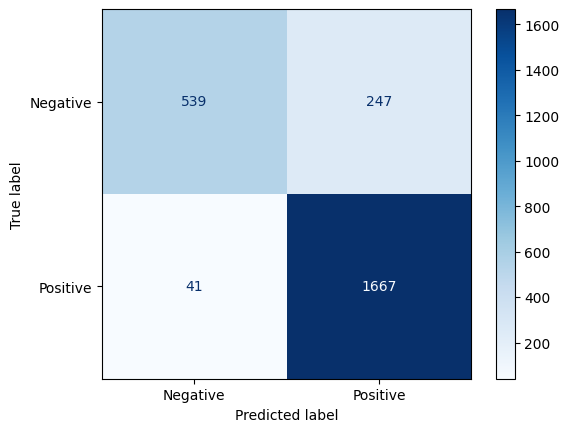

In [16]:
cmatrix_display_phrase = ConfusionMatrixDisplay(confusion_matrix = cmatrix_phrase, display_labels = ['Negative', 'Positive'])
cmatrix_display_phrase.plot(cmap = 'Blues')

##### Top Defects

In [17]:
coefficients_phrase = model_phrase.coef_[0]
feature_names_phrase = tfidf_phrase.get_feature_names_out()
coeff_df_phrase = pd.DataFrame({'Phrases': feature_names_phrase, 'Score': coefficients_phrase})

top_negative_phrase = coeff_df_phrase.sort_values(by = 'Score').head(20)

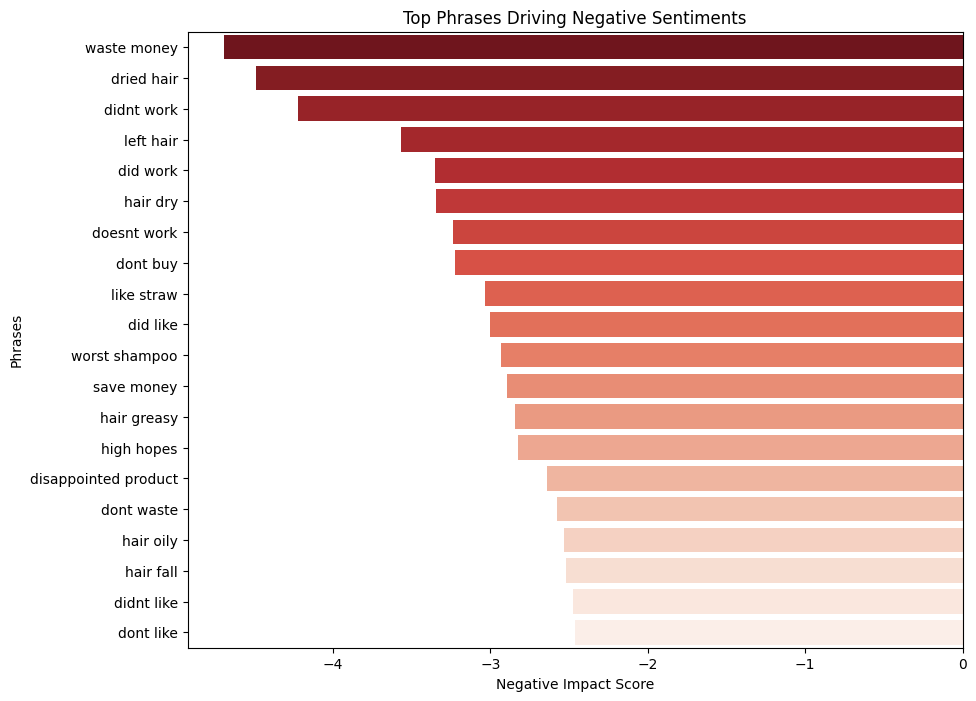

In [18]:
plt.figure(figsize = (10,8))
sns.barplot( x = 'Score', y = 'Phrases', data = top_negative_phrase, palette = 'Reds_r', hue = 'Phrases', legend = False)
plt.title('Top Phrases Driving Negative Sentiments')
plt.xlabel('Negative Impact Score')
plt.ylabel('Phrases')
plt.show()

In [19]:
cmatrix_words = confusion_matrix(y_test, y_pred)
cmatrix_words

array([[ 539,  247],
       [  41, 1667]])

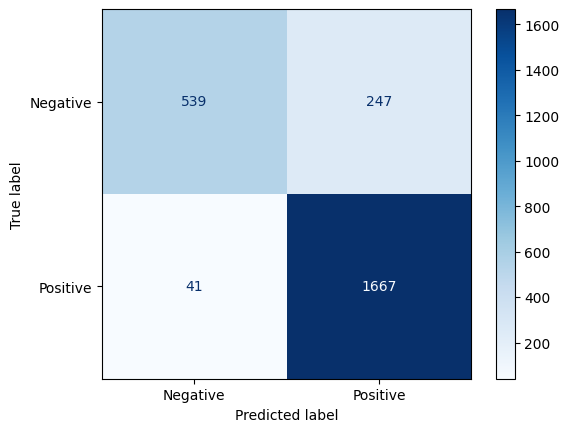

In [20]:
cmatrix_display_words = ConfusionMatrixDisplay(confusion_matrix = cmatrix_words, display_labels = ['Negative', 'Positive'])
cmatrix_display_words.plot(cmap = 'Blues')

In [21]:
coefficients_words = model_words.coef_[0]
feature_names_words = tfidf_words.get_feature_names_out()
coeff_df_words = pd.DataFrame({'Phrase': feature_names_words, 'Score': coefficients_words})

top_negative_words = coeff_df_words.sort_values(by = 'Score').head(20)

NameError: name 'model_words' is not defined

In [22]:
plt.figure(figsize = (10,8))
sns.barplot( x = 'Score', y = 'Phrase', data = top_negative_words, palette = 'Reds_r')
plt.title('Top Phrases Driving Negative Sentiments')
plt.xlabel('Negative Impact Score')
plt.ylabel('Phrases')
plt.show()

NameError: name 'top_negative_words' is not defined

<Figure size 1000x800 with 0 Axes>

### Aspect-Based Filtering

#### Vectorization and Model Training

In [13]:
# ----- Aspect-Based Filtering -----

product_aspects = [
    'hair', 'scalp', 'skin', 'head', 'face', 'ends', 'roots',
    'bottle', 'pump', 'cap', 'lid', 'box', 'packaging', 'container',
    'smell', 'scent', 'odor', 'fragrance', 'texture', 'foam', 'consistence', 'thick', 'runny',
    'residue', 'oil', 'grease', 'dandruff', 'flakes', 'moisture', 'volume', 'frizz', 'shine',
    'dryness', 'dry', 'breakage', 'loss', 'break', 'tangle', 'knot', 'clean', 
]

tfidf_filter = TfidfVectorizer(stop_words = 'english', max_features = 15000, ngram_range = (2, 2), min_df = 2)

X = tfidf_filter.fit_transform(df['cleaned_feedback'])
y = df['sentiment']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

model_filter = LogisticRegression(class_weight = 'balanced', max_iter = 1000)
model_filter.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


#### Evaluation of the Model

In [15]:
y_pred = model_filter.predict(X_test)

report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.83      0.84      0.83       786
           1       0.93      0.92      0.92      1708

    accuracy                           0.89      2494
   macro avg       0.88      0.88      0.88      2494
weighted avg       0.90      0.89      0.89      2494



In [16]:
cmatrix_filter = confusion_matrix(y_test, y_pred)
cmatrix_filter

array([[ 662,  124],
       [ 139, 1569]])

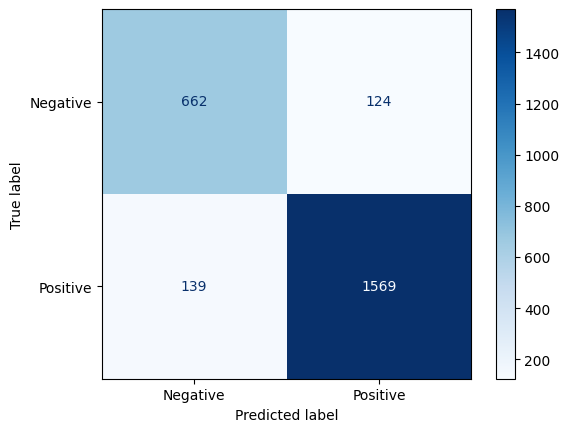

In [17]:
cmatrix_display_filter = ConfusionMatrixDisplay(confusion_matrix = cmatrix_filter, display_labels = ['Negative', 'Positive'])
cmatrix_display_filter.plot(cmap = 'Blues')

#### Top Defects

In [18]:
coefficients_filter = model_filter.coef_[0]
feature_names_filter = tfidf_filter.get_feature_names_out()
coeff_df_filter = pd.DataFrame({'Phrase': feature_names_filter, 'Score': coefficients_filter})

def has_aspect(phrase):
    return any(aspect in phrase for aspect in product_aspects)

coeff_df_filter['is_relevant'] = coeff_df_filter['Phrase'].apply(has_aspect)
relevant_df = coeff_df_filter[coeff_df_filter['is_relevant'] == True]

top_defects = relevant_df.sort_values(by = 'Score').head(20)

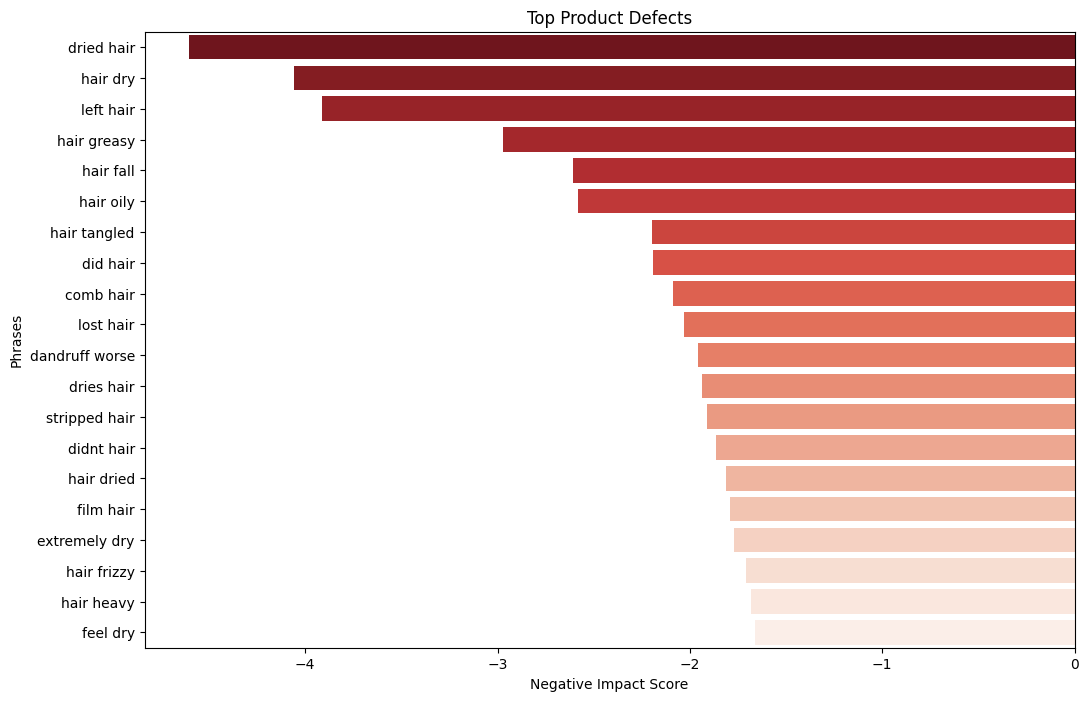

In [19]:
plt.figure(figsize = (12, 8))
sns.barplot(x = 'Score', y = 'Phrase', data = top_defects, palette = 'Reds_r', hue = 'Phrase', legend = False)
plt.title('Top Product Defects')
plt.xlabel('Negative Impact Score')
plt.ylabel('Phrases')
plt.show()

#### Checking reviews to see oily hair info

In [20]:
# ----- Why oily hair is there -----

pd.set_option('display.max_colwidth', None)  # shows the whole review text

oily_keywords = ['greasy', 'grease', 'oily', 'oil', 'residue', 'heavy', 'waxy']

oily_reviews = df[
    (df['sentiment'] == 0) &
    (df['cleaned_feedback'].str.contains('|'.join(oily_keywords)))
    ]

for index, row in oily_reviews[['review_title', 'review_text']].head(10).iterrows():
    print(f'title: {row['review_title']}')
    print(f'body: {row['review_text']}')
    print('-' * 50)


# 6 reviews out of 10 are actually about dry hair

title: Not a good product
body: This product dries out your hair leaves it oily and hair feels like there is a film on it. Would not recommend this product for colored or regular hair to anyone I know
--------------------------------------------------
title: Causes greasiness
body: Made hair greasy. Lots of leftover build up from conditioner.
--------------------------------------------------
title: Zero Stars!
body: I don’t normally leave reviews but since there was so many 5 star reviews I had to share. This is definitely not worthy of 5 stars. My hair was so damaged and falling out after having my son and I read all these “great” reviews. It was awful. I used it for 3 weeks and it made my hair super oily and feel filmy. I thought I needed to rinse more but it didn’t help. It smells awful too. I also could barely get a comb through my hair after using it. I would give this ZERO stars if possible
--------------------------------------------------
title: leaves hair dirty
body: This le